# Fashion Catalog Enrichment — Training Walkthrough

This notebook walks through the **same training pipeline** implemented in `src/train.py`, step by step, so you can see how the codebase fits together.

## What you will learn

1. How `configs/config.yaml` drives paths and hyperparameters
2. How raw Kaggle metadata becomes `train.csv` / `val.csv` / `labels.json`
3. How `FashionCatalogDataset` loads images and three label indices
4. How `MultiHeadFashionClassifier` shares one backbone for class, gender, and color
5. How training loss, weighted sampling, and validation metrics work
6. How to run the full training loop (same logic as the CLI)

## Prerequisites

From the repo root:

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
# Download dataset (see README) then:
python -m src.data_preparation --config configs/config.yaml
```

Run this notebook with the **repo root** as the working directory (Kernel → select folder containing `src/`).

## 0. Setup — point Python at the repo

In [1]:
from pathlib import Path
import os
import sys

# notebooks/ → repo root
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

# Drop cached `src.*` so edits to src/ are picked up without a full kernel restart.
for name in list(sys.modules):
    if name == "src" or name.startswith("src."):
        del sys.modules[name]

print("Repo root:", REPO_ROOT.resolve())
print("Working directory:", Path.cwd())

Repo root: /Users/atulagarwal/Documents/projects_scaler/fashion_catalog_enrichment_1
Working directory: /Users/atulagarwal/Documents/projects_scaler/fashion_catalog_enrichment_1


In [2]:
%load_ext autoreload
%autoreload 2

import json
from argparse import Namespace

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid

from src.data_preparation import create_splits, prepare_metadata
from src.dataset import FashionCatalogDataset, build_transforms
from src.model import build_model_from_label_info
from src.train import (
    TASKS,
    evaluate_one_epoch,
    make_class_weighted_losses,
    make_weighted_sampler,
    train,
)
from src.utils import count_trainable_parameters, ensure_dir, get_device, load_config, load_json, save_json, set_seed

%matplotlib inline

## 1. Load configuration

All scripts read `configs/config.yaml`. Key sections:

- **paths** — where raw/processed data and model outputs live
- **data** — which product classes to keep, label mappings, split sizes
- **training** — image size, batch size, epochs, loss weights, early stopping

In [3]:
CONFIG_PATH = REPO_ROOT / "configs/config.yaml"
config = load_config(CONFIG_PATH)

processed_dir = REPO_ROOT / config["paths"]["processed_dir"]
model_dir = REPO_ROOT / config["paths"]["model_dir"]
metrics_dir = REPO_ROOT / config["paths"]["metrics_dir"]

print("Project:", config["project"]["name"])
print("Image size:", config["training"]["image_size"])
print("Epochs (config):", config["training"]["epochs"])
print("Backbone options: efficientnet_b0, resnet50, mobilenet_v3_large")

Project: fashion_catalog_enrichment
Image size: 224
Epochs (config): 5
Backbone options: efficientnet_b0, resnet50, mobilenet_v3_large


## 2. Data preparation (if not done yet)

`src/data_preparation.py` does the following:

1. Read `data/raw/styles.csv` and map `articleType` → business **class** (Shirt, Shoes, …)
2. Map **gender** and **baseColour** → normalized labels
3. Keep rows with valid images under `data/raw/images/{id}.jpg`
4. Filter rare classes, optionally cap large classes
5. Build integer indices and stratified **train / val / test** splits

Set `RUN_DATA_PREP = True` only when raw data is present and processed CSVs are missing.

In [4]:
RUN_DATA_PREP = False  # flip to True once when you have data/raw/styles.csv + images

train_csv = processed_dir / "train.csv"
labels_json = processed_dir / "labels.json"

raw_csv = REPO_ROOT / config["paths"]["raw_metadata_csv"]
raw_images = REPO_ROOT / config["paths"]["raw_image_dir"]

print("Raw metadata exists:", raw_csv.exists())
print("Raw images dir exists:", raw_images.exists())
print("Processed train.csv exists:", train_csv.exists())

if RUN_DATA_PREP:
    set_seed(config["project"]["seed"])
    ensure_dir(processed_dir)
    df, artifacts = prepare_metadata(config)
    splits = create_splits(df, config)
    df.to_csv(processed_dir / "metadata_processed.csv", index=False)
    for split_name, split_df in splits.items():
        split_df.to_csv(processed_dir / f"{split_name}.csv", index=False)
    save_json(artifacts["label_info"], labels_json)
    save_json(artifacts["eda_summary"], processed_dir / "eda_summary.json")
    print("Data preparation finished.")
    print(json.dumps(artifacts["eda_summary"], indent=2))
elif not train_csv.exists():
    raise FileNotFoundError(
        "Missing processed data. Download the Kaggle dataset, then run:\n"
        "  python -m src.data_preparation --config configs/config.yaml\n"
        "Or set RUN_DATA_PREP = True in the cell above."
    )

Raw metadata exists: True
Raw images dir exists: True
Processed train.csv exists: True


## 3. Explore processed labels

Each row in `train.csv` has `image_path` plus three target indices used by the model.

In [5]:
train_df = pd.read_csv(train_csv)
label_info = load_json(labels_json)

print(f"Train rows: {len(train_df):,}")
print(f"Classes: {label_info['class']['num_classes']} | Genders: {label_info['gender']['num_classes']} | Colors: {label_info['color']['num_classes']}")
display(train_df[["image_path", "class_label", "gender_label", "color_label", "class_idx", "gender_idx", "color_idx"]].head())

Train rows: 14,602
Classes: 8 | Genders: 4 | Colors: 15


,image_path,class_label,gender_label,color_label,class_idx,gender_idx,color_idx
0,data/raw/images/51407.jpg,Shirt,Men,Blue,3,1,2
1,data/raw/images/11101.jpg,Shirt,Men,Purple,3,1,10
2,data/raw/images/20507.jpg,Bag,Women,Black,0,3,1
3,data/raw/images/12043.jpg,Shirt,Men,White,3,1,13
4,data/raw/images/14726.jpg,T-Shirt,Men,Purple,6,1,10


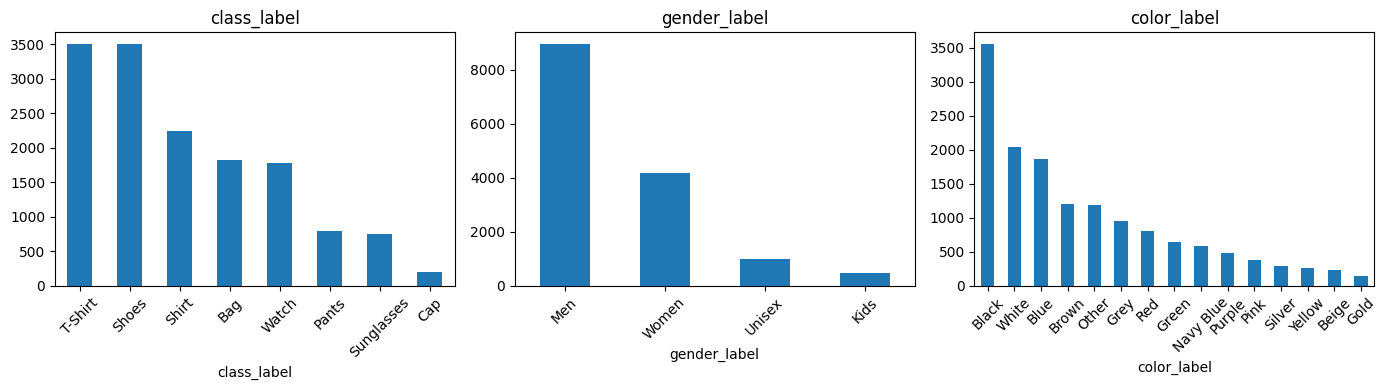

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["class_label", "gender_label", "color_label"]):
    train_df[col].value_counts().plot(kind="bar", ax=ax, rot=45)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. `FashionCatalogDataset` — one training example

Defined in `src/dataset.py`:

- Opens the image path from CSV
- Applies transforms (augmentation on train, resize+normalize on val)
- Returns a dict: `image` tensor + `targets` dict with `class`, `gender`, `color` indices

In [7]:
image_size = config["training"]["image_size"]

# Paths in CSV are relative to REPO_ROOT (not notebooks/).
first_image = REPO_ROOT / train_df.iloc[0]["image_path"]
assert first_image.exists(), f"Missing image: {first_image}. Download dataset / run data prep (see README)."

train_ds = FashionCatalogDataset(
    train_csv, transform=build_transforms(image_size, train=True), root_dir=REPO_ROOT
)
val_csv = processed_dir / "val.csv"
val_ds = FashionCatalogDataset(
    val_csv, transform=build_transforms(image_size, train=False), root_dir=REPO_ROOT
)

sample = train_ds[0]
print("Image tensor shape:", sample["image"].shape)
print("Targets:", {k: int(v) for k, v in sample["targets"].items()})
print("Path:", sample["image_path"])

Image tensor shape: torch.Size([3, 224, 224])
Targets: {'class': 3, 'gender': 1, 'color': 2}
Path: /Users/atulagarwal/Documents/projects_scaler/fashion_catalog_enrichment_1/data/raw/images/51407.jpg


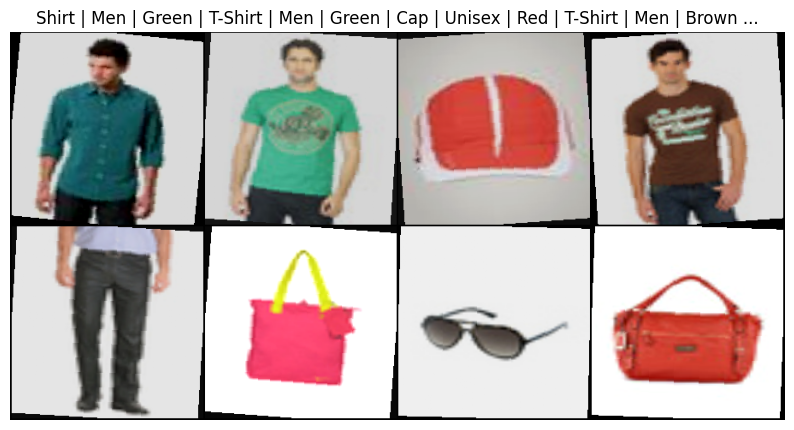

In [8]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean


def show_batch(dataset, n=8):
    loader = DataLoader(dataset, batch_size=n, shuffle=True)
    batch = next(iter(loader))
    grid = make_grid(denormalize(batch["image"]), nrow=4)
    plt.figure(figsize=(10, 6))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.axis("off")
    titles = []
    for i in range(n):
        c = int(batch["targets"]["class"][i])
        g = int(batch["targets"]["gender"][i])
        col = int(batch["targets"]["color"][i])
        titles.append(
            f"{label_info['class']['idx_to_label'][str(c)]} | "
            f"{label_info['gender']['idx_to_label'][str(g)]} | "
            f"{label_info['color']['idx_to_label'][str(col)]}"
        )
    plt.title(" | ".join(titles[:4]) + " ...")
    plt.show()


show_batch(train_ds)

## 5. Model — shared backbone, three heads

`src/model.py` builds a pretrained CNN (default: **EfficientNet-B0**), removes its original classifier, and attaches three linear heads:

```text
image -> backbone -> shared features -> class_head
                                      -> gender_head
                                      -> color_head
```

Forward pass returns a dict: `{"class": logits, "gender": logits, "color": logits}`.

In [9]:
BACKBONE = "efficientnet_b0"  # try: resnet50, mobilenet_v3_large
device = get_device()
set_seed(config["project"]["seed"])

model = build_model_from_label_info(
    label_info,
    BACKBONE,
    dropout=config["training"]["dropout"],
    pretrained=True,
).to(device)

print("Device:", device)
print("Trainable parameters:", f"{count_trainable_parameters(model):,}")
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/atulagarwal/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 14.1MB/s]

Device: cpu
Trainable parameters: 4,042,135
MultiHeadFashionClassifier(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), st

## 6. Loss, sampling, and DataLoaders

Training uses two imbalance tools from `src/train.py`:

1. **WeightedRandomSampler** — oversamples rare product classes
2. **Class-weighted CrossEntropyLoss** — per task (class / gender / color)

Total loss = weighted sum of the three task losses (`loss_weights` in config).

In [10]:
batch_size = config["training"]["batch_size"]
sampler = make_weighted_sampler(train_csv) if config["training"].get("use_weighted_sampler", True) else None

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=sampler is None,
    sampler=sampler,
    num_workers=0,  # use 0 in notebooks; scripts use config num_workers
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

criterion_dict = make_class_weighted_losses(train_csv, label_info, device)
loss_weights = config["training"]["loss_weights"]
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["training"]["learning_rate"],
    weight_decay=config["training"]["weight_decay"],
)

print("Loss weights:", loss_weights)

Loss weights: {'class': 1.0, 'gender': 0.7, 'color': 0.8}


/Users/atulagarwal/Documents/projects_scaler/fashion_catalog_enrichment_1/src/train.py:28: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  return WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=len(sample_weights), replacement=True)


## 7. One training step (manual)

This mirrors the inner loop in `train()` — useful to see tensors flowing through the model.

In [11]:
model.train()
batch = next(iter(train_loader))

images = batch["image"].to(device)
targets = {task: batch["targets"][task].to(device) for task in TASKS}

optimizer.zero_grad()
outputs = model(images)

task_losses = {
    task: criterion_dict[task](outputs[task], targets[task])
    for task in TASKS
}
loss = sum(loss_weights[task] * task_losses[task] for task in TASKS)
loss.backward()
optimizer.step()

print("Batch shape:", tuple(images.shape))
for task in TASKS:
    print(f"  {task} logits:", tuple(outputs[task].shape), "| loss:", round(task_losses[task].item(), 4))
print("Combined loss:", round(loss.item(), 4))

Batch shape: (32, 3, 224, 224)
  class logits: (32, 8) | loss: 2.1202
  gender logits: (32, 4) | loss: 1.467
  color logits: (32, 15) | loss: 2.7528
Combined loss: 5.3494


## 8. Mini training — 1 epoch on a small subset

Run this cell to practice without waiting for full training. Increase `SUBSET_SIZE` or set `USE_FULL_DATA = True` when ready.

In [12]:
USE_FULL_DATA = False
SUBSET_SIZE = 512  # only used when USE_FULL_DATA is False

if USE_FULL_DATA:
    mini_train_ds = train_ds
else:
    mini_train_ds = Subset(train_ds, list(range(min(SUBSET_SIZE, len(train_ds)))))

mini_loader = DataLoader(mini_train_ds, batch_size=batch_size, shuffle=True, num_workers=0)

model.train()
running_loss = 0.0
for batch in mini_loader:
    images = batch["image"].to(device)
    targets = {task: batch["targets"][task].to(device) for task in TASKS}
    optimizer.zero_grad()
    outputs = model(images)
    batch_loss = sum(loss_weights[task] * criterion_dict[task](outputs[task], targets[task]) for task in TASKS)
    batch_loss.backward()
    optimizer.step()
    running_loss += batch_loss.item() * images.size(0)

train_loss = running_loss / len(mini_train_ds)
val_metrics = evaluate_one_epoch(model, val_loader, criterion_dict, loss_weights, device)

print(f"Mini train loss: {train_loss:.4f}")
print("Validation metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in val_metrics.items()})

# Kept for the visualization cell below
mini_train_loss = train_loss
mini_val_metrics = val_metrics

Mini train loss: 4.6466
Validation metrics: {'loss': 4.0289, 'class_accuracy': 0.7616, 'class_macro_f1': 0.7075, 'gender_accuracy': 0.5682, 'gender_macro_f1': 0.4387, 'color_accuracy': 0.1908, 'color_macro_f1': 0.1174, 'joint_accuracy': np.float64(0.0684)}


## 8b. Visualize mini-training metrics

**Train loss** — average wrongness on the 512 training images you just learned from (lower is better).

**Val loss** — same formula on the **validation** set (images not used in that mini-train loop).

| Metric | Plain meaning |
|--------|----------------|
| `class_accuracy` | % of val images where product type (Shirt, Bag, …) is correct |
| `gender_accuracy` | % where gender is correct |
| `color_accuracy` | % where color is correct |
| `*_macro_f1` | Like accuracy but **each label counts equally** (fair when some colors/classes are rare) |
| `joint_accuracy` | % where **all three** are correct on the **same** image (strictest score) |

After **one epoch on 512 images**, weak color/joint scores are normal. Class often learns fastest; color has more choices (15 labels).

In [ ]:
import numpy as np
import pandas as pd


def plot_mini_training_metrics(train_loss, val_metrics):
    """Scorecard charts for mini-training (run cell above first)."""
    tasks = ["class", "gender", "color"]
    acc = [float(val_metrics[f"{t}_accuracy"]) for t in tasks]
    f1 = [float(val_metrics[f"{t}_macro_f1"]) for t in tasks]
    joint = float(val_metrics["joint_accuracy"])
    vloss = float(val_metrics["loss"])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

    # 1) Side-by-side bars per task
    x = np.arange(len(tasks))
    width = 0.36
    axes[0].bar(x - width / 2, acc, width, label="Accuracy", color="#4C78A8")
    axes[0].bar(x + width / 2, f1, width, label="Macro F1", color="#F58518")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([t.capitalize() for t in tasks])
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Score (1.0 = perfect)")
    axes[0].set_title("Validation: each prediction task")
    axes[0].legend(loc="upper right")
    for i, (a, fv) in enumerate(zip(acc, f1)):
        axes[0].text(i - width / 2, a + 0.02, f"{a:.0%}", ha="center", fontsize=9)
        axes[0].text(i + width / 2, fv + 0.02, f"{fv:.0%}", ha="center", fontsize=9)

    # 2) Loss + joint accuracy
    axes[1].barh(["Train loss\n(mini subset)", "Val loss\n(full val set)"], [train_loss, vloss], color=["#72B7B2", "#E45756"])
    axes[1].set_xlabel("Loss (lower is better)")
    axes[1].set_title("Loss comparison")
    axes[1].invert_yaxis()
    for i, v in enumerate([train_loss, vloss]):
        axes[1].text(v + 0.05, i, f"{v:.3f}", va="center", fontsize=10)

    # 3) Joint accuracy + table
    axes[2].axis("off")
    axes[2].set_title(f"Joint accuracy: {joint:.1%}\n(all 3 labels right)")
    scorecard = pd.DataFrame(
        {
            "Task": [t.capitalize() for t in tasks],
            "Accuracy": [f"{a:.1%}" for a in acc],
            "Macro F1": [f"{f:.1%}" for f in f1],
        }
    )
    table = axes[2].table(
        cellText=scorecard.values,
        colLabels=scorecard.columns,
        loc="center",
        cellLoc="center",
    )
    table.scale(1.15, 1.6)

    plt.suptitle("Mini-training scorecard (1 epoch, small subset)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

    # Optional: how often each task is correct (venn-style intuition)
    fig2, ax2 = plt.subplots(figsize=(5, 3))
    ax2.bar(["Class only\n(correct)", "Gender only", "Color only", "All three\n(joint)"], 
            [acc[0], acc[1], acc[2], joint], color=["#4C78A8", "#72B7B2", "#F58518", "#54A24B"])
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("Fraction correct on val set")
    ax2.set_title("Why joint accuracy is low: must get ALL three right")
    for i, v in enumerate([acc[0], acc[1], acc[2], joint]):
        ax2.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_mini_training_metrics(mini_train_loss, mini_val_metrics)

## 9. Full training — same as CLI

This calls `train()` from `src/train.py` (identical to):

```bash
python -m src.train --config configs/config.yaml --backbone efficientnet_b0
```

Outputs:

- `outputs/models/best_model.pt`
- `outputs/models/best_model_{backbone}.pt`
- `outputs/metrics/training_history_{backbone}.json`

Set `RUN_FULL_TRAINING = True` when you are ready (may take a while on CPU).

In [ ]:
RUN_FULL_TRAINING = False

train_args = Namespace(
    config=str(CONFIG_PATH),
    backbone=BACKBONE,
    no_pretrained=False,
)

if RUN_FULL_TRAINING:
    train(train_args)
else:
    print("Skipped full training. Set RUN_FULL_TRAINING = True to run.")
    print("CLI equivalent:")
    print(f"  python -m src.train --config configs/config.yaml --backbone {BACKBONE}")

## 10. Inspect training history (after full training)

Plot validation macro F1 per task across epochs.

In [ ]:
history_path = metrics_dir / f"training_history_{BACKBONE}.json"
if not history_path.exists():
    print(f"No history yet at {history_path}. Run full training first.")
else:
    history = load_json(history_path)["history"]
    hist_df = pd.DataFrame(history)
    display(hist_df.tail())

    fig, ax = plt.subplots(figsize=(8, 4))
    for task in TASKS:
        ax.plot(hist_df["epoch"], hist_df[f"{task}_macro_f1"], marker="o", label=f"{task} macro F1")
    ax.plot(hist_df["epoch"], hist_df["avg_val_macro_f1"], marker="s", linewidth=2, label="avg (early-stop metric)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.legend()
    ax.set_title("Validation macro F1 per epoch")
    plt.tight_layout()
    plt.show()

## 11. Quick inference smoke test (after checkpoint exists)

Uses `FashionCatalogPredictor` from `src/inference.py` — same class the Streamlit app uses.

In [ ]:
from src.inference import FashionCatalogPredictor

checkpoint = model_dir / "best_model.pt"
if not checkpoint.exists():
    print(f"Checkpoint not found: {checkpoint}")
else:
    predictor = FashionCatalogPredictor(checkpoint)
    result = predictor.predict_image_path(train_df.iloc[0]["image_path"])
    print(json.dumps(result, indent=2))

## Map notebook sections → source files

| Notebook step | Source file |
|---------------|-------------|
| Config | `configs/config.yaml`, `src/utils.py` |
| Data prep | `src/data_preparation.py`, `src/label_mapping.py` |
| Dataset & transforms | `src/dataset.py` |
| Model | `src/model.py` |
| Train / eval loop | `src/train.py` |
| Inference | `src/inference.py` |
| Streamlit UI | `app/streamlit_app.py` |

**Suggested order:** run cells 0–7 first, then mini training (8), then full training (9) when data is ready.

In [13]:

print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

True
True
